# Box and whisker plot
A box and whisker plot (box plot) displays the five-number summary of a set of data. The five-number summary is the minimum, first quartile, median, third quartile, and maximum.
In a box plot, we draw a box from the first quartile to the third quartile. A vertical line goes through the box at the median. The whiskers go from each quartile to the minimum or maximum.

<img src="img/1.png" alt="box plot" width="500"/>

## Interpreting quartiles
The five-number summary divides the data into sections that each contain approximately $25\%$ of the data in that set.
<img src="img/2.png" alt="box plot interpreting" width="500"/>

The following python script processes, analyzes, and visualizes Turbulent Kinetic Energy (TKE) data from multiple CSV files, each representing a different region.ns

Bar Plot: Compares average TKE across regions.

Box Plot: Shows TKE variability/distribution across regio.

### Key Elements in the Plot
Red Circles: Actual TKE values (jittered horizontally).

Gold Diamond (◊): Mean TKE for the region (enabled by showmeans=True).

Black Line: Median TKE (central line in the box).

Box Edges: 25th (Q1) and 75th (Q3) percentiles.

Whiskers: min/max values within that range.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12  # Default font size
mpl.rcParams['axes.titlesize'] = 14  # Title font size
mpl.rcParams['axes.labelsize'] = 12  # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10  # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10  # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10  # Legend font size

sns.set_context("notebook", font_scale=1.2, rc={"font.family": "Times New Roman"})

def process_csv_files(directory_path):
    """
    Processes CSV files containing TKE data for different regions.
    """
    regions_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            region_name = os.path.splitext(file_name)[0]
            file_path = os.path.join(directory_path, file_name)
            data = pd.read_csv(file_path)
            if {'K', 'Points:0', 'Points:1', 'Points:2'}.issubset(data.columns):
                data.rename(columns={'K': 'TKE', 'Points:0': 'x', 'Points:1': 'y', 'Points:2': 'z'}, inplace=True)
                regions_data[region_name] = data
            else:
                print(f"Warning: File '{file_name}' has missing required columns.")
    return regions_data

def calculate_statistics(data, column):
    """
    Calculates statistics for a given column.
    """
    return {
        "mean": data[column].mean(),
        "median": data[column].median(),
        "variance": data[column].var()
    }

def generate_visualizations(regions_data):
    """
    Generates improved visualizations with enhanced box plot.
    """
    # Sort regions for consistent ordering
    regions = sorted(regions_data.keys())

    # --- Bar Plot (unchanged) ---
    avg_tke = {region: calculate_statistics(data, 'TKE')['mean'] for region, data in regions_data.items()}
    plt.bar(avg_tke.keys(), avg_tke.values(), color='blue')
    plt.title('Average TKE per Region-HO1' , fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel('TKE', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("AVGTKE-ND-HO1.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Improved Box Plot ---
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")  # Cleaner background
    
    # Prepare data with NaN handling
    tke_values = [regions_data[region]['TKE'].dropna().values for region in regions]
    
    # Create box plot with enhanced styling
    box = plt.boxplot(
        tke_values,
        labels=regions,
        patch_artist=True,
        showmeans=True,
        showfliers=False,  # Disable default outlier circles
        meanprops={'marker':'D', 'markerfacecolor':'gold', 'markersize':8},
        medianprops={'color':'black', 'linewidth':2},
        boxprops={'facecolor':'lightblue', 'edgecolor':'gray'},
        whiskerprops={'color':'gray'},
        capprops={'color':'gray'}
    )
    
    # Add jittered data points
    #for i, region in enumerate(regions):
     #   x = np.random.normal(i+1, 0.04, size=len(tke_values[i]))
      #  plt.plot(x, tke_values[i], 'r.', alpha=0.4, markersize=5, zorder=0)
    
    plt.title('TKE Distribution Across Regions (HO1)', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel('TKE', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45, ha='right')
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)

    #plt.ylim(0, None)  # Auto-scale y-axis
    plt.ylim(-0.01, None)  # Auto-scale y-axis
    #plt.yticks(np.arange(-0.01, plt.ylim()[1] + 0.01, 0.01))  # Adjust y-axis ticks every 0.01
    
    plt.tight_layout()
    plt.savefig("TKE_Variability-ND-HO1.png", dpi=300, bbox_inches='tight')
    plt.show()

def main():
    directory_path = './New/HO1'
    regions_data = process_csv_files(directory_path)
    
    for region, data in regions_data.items():
        stats = calculate_statistics(data, 'TKE')
        print(f"Statistics for {region}:")
        print(f"Mean: {stats['mean']:.4f}, Median: {stats['median']:.4f}, Variance: {stats['variance']:.6f}\n")
    
    generate_visualizations(regions_data)

if __name__ == "__main__":
    main()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12  # Default font size
mpl.rcParams['axes.titlesize'] = 14  # Title font size
mpl.rcParams['axes.labelsize'] = 12  # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10  # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10  # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10  # Legend font size

sns.set_context("notebook", font_scale=1.2, rc={"font.family": "Times New Roman"})

def process_csv_files(directory_path):
    """
    Processes CSV files containing TKE data for different regions.
    """
    regions_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            region_name = os.path.splitext(file_name)[0]
            file_path = os.path.join(directory_path, file_name)
            data = pd.read_csv(file_path)
            if {'K-dim', 'Points:0', 'Points:1', 'Points:2'}.issubset(data.columns):
                data.rename(columns={'K-dim': 'TKE', 'Points:0': 'x', 'Points:1': 'y', 'Points:2': 'z'}, inplace=True)
                regions_data[region_name] = data
            else:
                print(f"Warning: File '{file_name}' has missing required columns.")
    return regions_data

def calculate_statistics(data, column):
    """
    Calculates statistics for a given column.
    """
    return {
        "mean": data[column].mean(),
        "median": data[column].median(),
        "variance": data[column].var()
    }

def generate_visualizations(regions_data):
    """
    Generates improved visualizations with enhanced box plot.
    """
    # Sort regions for consistent ordering
    regions = sorted(regions_data.keys())

    # --- Bar Plot (unchanged) ---
    avg_tke = {region: calculate_statistics(data, 'TKE')['mean'] for region, data in regions_data.items()}
    plt.bar(avg_tke.keys(), avg_tke.values(), color='blue')
    plt.title('Average TKE per Region-HS' , fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel(r'TKE ($m^2/s^2$)', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("AVGTKE-HS.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Improved Box Plot ---
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")  # Cleaner background
    
    # Prepare data with NaN handling
    tke_values = [regions_data[region]['TKE'].dropna().values for region in regions]
    
    # Create box plot with enhanced styling
    box = plt.boxplot(
        tke_values,
        labels=regions,
        patch_artist=True,
        showmeans=True,
        showfliers=False,  # Disable default outlier circles
        meanprops={'marker':'D', 'markerfacecolor':'gold', 'markersize':8},
        medianprops={'color':'black', 'linewidth':2},
        boxprops={'facecolor':'lightblue', 'edgecolor':'gray'},
        whiskerprops={'color':'gray'},
        capprops={'color':'gray'}
    )
    
    # Add jittered data points
    #for i, region in enumerate(regions):
     #   x = np.random.normal(i+1, 0.04, size=len(tke_values[i]))
      #  plt.plot(x, tke_values[i], 'r.', alpha=0.4, markersize=5, zorder=0)
    
    plt.title('TKE Distribution Across Regions (HS)', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel(r'TKE $(\mathrm{m^2/s^2})$', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45, ha='right')
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)

    #plt.ylim(0, None)  # Auto-scale y-axis
    plt.ylim(-0.01, None)  # Auto-scale y-axis
    #plt.yticks(np.arange(-0.01, plt.ylim()[1] + 0.1, 0.01))  # Adjust y-axis ticks every 0.01
    
    plt.tight_layout()
    plt.savefig("TKE_Variability-HS.png", dpi=300, bbox_inches='tight')
    plt.show()

def main():
    directory_path = './New/HS'
    regions_data = process_csv_files(directory_path)
    
    for region, data in regions_data.items():
        stats = calculate_statistics(data, 'TKE')
        print(f"Statistics for {region}:")
        print(f"Mean: {stats['mean']:.4f}, Median: {stats['median']:.4f}, Variance: {stats['variance']:.6f}\n")
    
    generate_visualizations(regions_data)

if __name__ == "__main__":
    main()

### Reynolds stress:

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12  # Default font size
mpl.rcParams['axes.titlesize'] = 14  # Title font size
mpl.rcParams['axes.labelsize'] = 12  # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10  # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10  # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10  # Legend font size

sns.set_context("notebook", font_scale=1.2, rc={"font.family": "Times New Roman"})

def process_csv_files(directory_path):
    """
    Processes CSV files containing TKE data for different regions.
    """
    regions_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            region_name = os.path.splitext(file_name)[0]
            file_path = os.path.join(directory_path, file_name)
            data = pd.read_csv(file_path)
            if {'uw', 'Points:0', 'Points:1', 'Points:2'}.issubset(data.columns):
                data.rename(columns={'uw': 'upwp', 'Points:0': 'x', 'Points:1': 'y', 'Points:2': 'z'}, inplace=True)
                regions_data[region_name] = data
            else:
                print(f"Warning: File '{file_name}' has missing required columns.")
    return regions_data

def calculate_statistics(data, column):
    """
    Calculates statistics for a given column.
    """
    return {
        "mean": data[column].mean(),
        "median": data[column].median(),
        "variance": data[column].var()
    }

def generate_visualizations(regions_data):
    """
    Generates improved visualizations with enhanced box plot.
    """
    # Sort regions for consistent ordering
    regions = sorted(regions_data.keys())

    # --- Bar Plot (unchanged) ---
    avg_upwp = {region: calculate_statistics(data, 'upwp')['mean'] for region, data in regions_data.items()}
    plt.bar(avg_upwp.keys(), avg_upwp.values(), color='red')
    plt.title('Average out of plane Reynolds stress per Region-MS' , fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel("u'w'", fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("AVGupwp-ND-MS.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Improved Box Plot ---
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")  # Cleaner background
    
    # Prepare data with NaN handling
    upwp_values = [regions_data[region]['upwp'].dropna().values for region in regions]
    
    # Create box plot with enhanced styling
    box = plt.boxplot(
        upwp_values,
        labels=regions,
        patch_artist=True,
        showmeans=True,
        showfliers=False,  # Disable default outlier circles
        meanprops={'marker':'D', 'markerfacecolor':'gold', 'markersize':8},
        medianprops={'color':'black', 'linewidth':2},
        boxprops={'facecolor':'blue', 'edgecolor':'gray'},
        whiskerprops={'color':'gray'},
        capprops={'color':'gray'}
    )
    
    # Add jittered data points
    #for i, region in enumerate(regions):
     #   x = np.random.normal(i+1, 0.04, size=len(tke_values[i]))
      #  plt.plot(x, tke_values[i], 'r.', alpha=0.4, markersize=5, zorder=0)
    
    plt.title("Reynolds stress u'w' Distribution Across Regions (MS)", fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel("u'w'", fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45, ha='right')
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)

    #plt.ylim(0, None)  # Auto-scale y-axis
    plt.ylim(None, None)  # Auto-scale y-axis
    #plt.yticks(np.arange(-0.01, plt.ylim()[1] + 0.01, 0.01))  # Adjust y-axis ticks every 0.01
    
    plt.tight_layout()
    plt.savefig("upwp_Variability-ND-MS.png", dpi=300, bbox_inches='tight')
    plt.show()

def main():
    directory_path = './New/MS'
    regions_data = process_csv_files(directory_path)
    
    for region, data in regions_data.items():
        stats = calculate_statistics(data, 'upwp')
        print(f"Statistics for {region}:")
        print(f"Mean: {stats['mean']:.4f}, Median: {stats['median']:.4f}, Variance: {stats['variance']:.6f}\n")
    
    generate_visualizations(regions_data)

if __name__ == "__main__":
    main()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12  # Default font size
mpl.rcParams['axes.titlesize'] = 14  # Title font size
mpl.rcParams['axes.labelsize'] = 12  # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10  # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10  # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10  # Legend font size

sns.set_context("notebook", font_scale=1.2, rc={"font.family": "Times New Roman"})

def process_csv_files(directory_path):
    """
    Processes CSV files containing TKE data for different regions.
    """
    regions_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            region_name = os.path.splitext(file_name)[0]
            file_path = os.path.join(directory_path, file_name)
            data = pd.read_csv(file_path)
            if {'uw-dim', 'Points:0', 'Points:1', 'Points:2'}.issubset(data.columns):
                data.rename(columns={'uw-dim': 'upwp', 'Points:0': 'x', 'Points:1': 'y', 'Points:2': 'z'}, inplace=True)
                regions_data[region_name] = data
            else:
                print(f"Warning: File '{file_name}' has missing required columns.")
    return regions_data

def calculate_statistics(data, column):
    """
    Calculates statistics for a given column.
    """
    return {
        "mean": data[column].mean(),
        "median": data[column].median(),
        "variance": data[column].var()
    }

def generate_visualizations(regions_data):
    """
    Generates improved visualizations with enhanced box plot.
    """
    # Sort regions for consistent ordering
    regions = sorted(regions_data.keys())

    # --- Bar Plot (unchanged) ---
    avg_upwp = {region: calculate_statistics(data, 'upwp')['mean'] for region, data in regions_data.items()}
    plt.bar(avg_upwp.keys(), avg_upwp.values(), color='red')
    plt.title('Average out of plane Reynolds stress per Region-HO1' , fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel(r"u'w' $(\mathrm{m^2/s^2})$", fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("AVGupwp-HO1.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Improved Box Plot ---
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")  # Cleaner background
    
    # Prepare data with NaN handling
    upwp_values = [regions_data[region]['upwp'].dropna().values for region in regions]
    
    # Create box plot with enhanced styling
    box = plt.boxplot(
        upwp_values,
        labels=regions,
        patch_artist=True,
        showmeans=True,
        showfliers=False,  # Disable default outlier circles
        meanprops={'marker':'D', 'markerfacecolor':'gold', 'markersize':8},
        medianprops={'color':'black', 'linewidth':2},
        boxprops={'facecolor':'blue', 'edgecolor':'gray'},
        whiskerprops={'color':'gray'},
        capprops={'color':'gray'}
    )
    
    # Add jittered data points
    #for i, region in enumerate(regions):
     #   x = np.random.normal(i+1, 0.04, size=len(tke_values[i]))
      #  plt.plot(x, tke_values[i], 'r.', alpha=0.4, markersize=5, zorder=0)
    
    plt.title("Reynolds stress u'w' Distribution Across Regions (HO1)", fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel(r"u'w' $(\mathrm{m^2/s^2})$", fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45, ha='right')
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)

    #plt.ylim(0, None)  # Auto-scale y-axis
    plt.ylim(None, None)  # Auto-scale y-axis
    #plt.yticks(np.arange(-0.01, plt.ylim()[1] + 0.01, 0.01))  # Adjust y-axis ticks every 0.01
    
    plt.tight_layout()
    plt.savefig("upwp_Variability-HO1.png", dpi=300, bbox_inches='tight')
    plt.show()

def main():
    directory_path = './New/HO1'
    regions_data = process_csv_files(directory_path)
    
    for region, data in regions_data.items():
        stats = calculate_statistics(data, 'upwp')
        print(f"Statistics for {region}:")
        print(f"Mean: {stats['mean']:.4f}, Median: {stats['median']:.4f}, Variance: {stats['variance']:.6f}\n")
    
    generate_visualizations(regions_data)

if __name__ == "__main__":
    main()

### Turbulence intensity (TI):

$$ \text{TI} = \frac{\sqrt{\frac{2}{3} \cdot \text{TKE}}}{U_{\text{mean}}} \times 100 \, (\%) $$

We should ensure Ensure TKE is dimensional and not already normalized.ormalized.

Statistics for Region 'a':
Mean TI: 1.33%, Median TI: 1.32%, Variance: 0.0578

Statistics for Region 'b':
Mean TI: 1.32%, Median TI: 1.31%, Variance: 0.0176

Statistics for Region 'c':
Mean TI: 1.29%, Median TI: 1.23%, Variance: 0.0505

Statistics for Region 'd':
Mean TI: 1.60%, Median TI: 1.48%, Variance: 0.5429

Statistics for Region 'e':
Mean TI: 1.63%, Median TI: 1.41%, Variance: 0.7083

Statistics for Region 'f':
Mean TI: 1.62%, Median TI: 1.64%, Variance: 0.4623

Statistics for Region 'g':
Mean TI: 3.61%, Median TI: 3.64%, Variance: 3.4073

Statistics for Region 'h':
Mean TI: 4.77%, Median TI: 4.95%, Variance: 4.4086

Statistics for Region 'i':
Mean TI: 2.07%, Median TI: 1.98%, Variance: 0.6625

Statistics for Region 'j':
Mean TI: 2.86%, Median TI: 2.86%, Variance: 0.3721

Statistics for Region 'k':
Mean TI: 3.46%, Median TI: 3.40%, Variance: 0.3824

Statistics for Region 'l':
Mean TI: 2.35%, Median TI: 2.42%, Variance: 0.6249



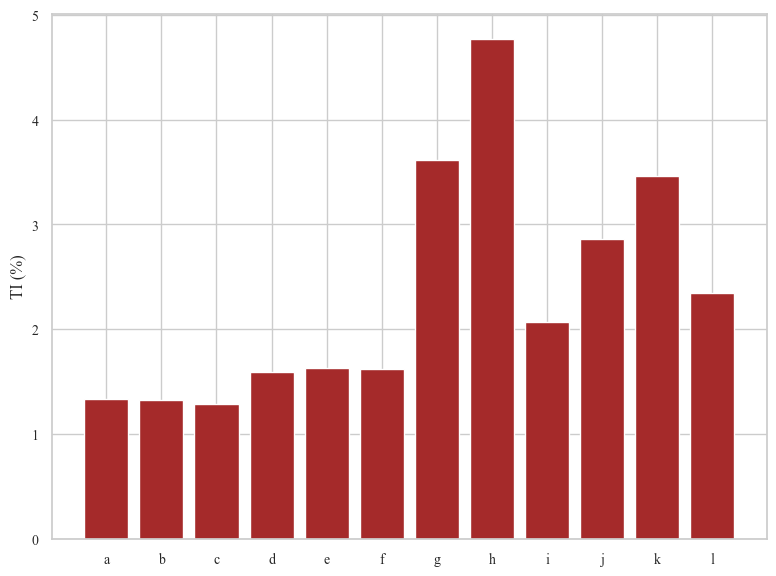

C:\Users\Student\AppData\Local\Temp\ipykernel_15660\1380621314.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


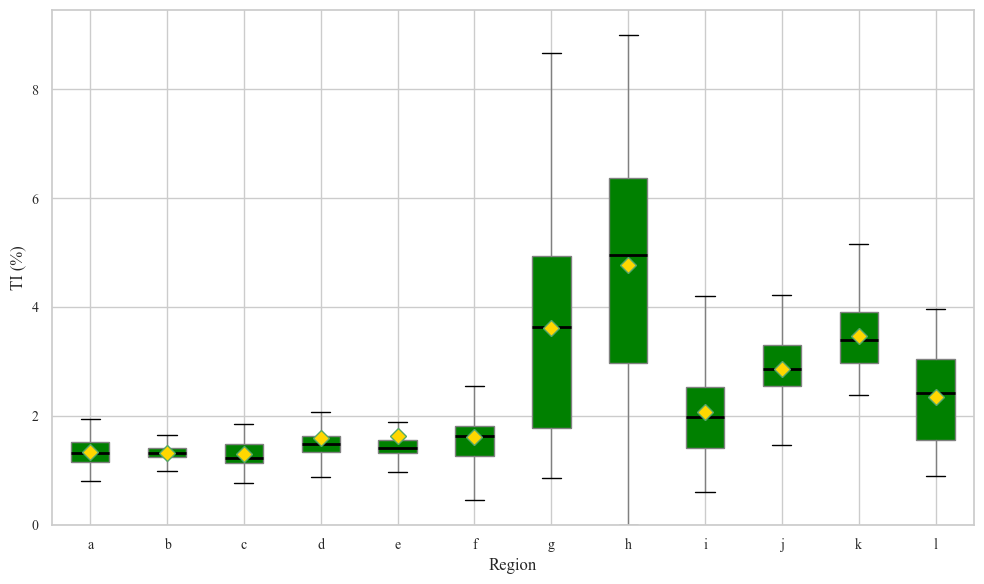

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12  # Default font size
mpl.rcParams['axes.titlesize'] = 14  # Title font size
mpl.rcParams['axes.labelsize'] = 12  # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10  # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10  # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10  # Legend font size

sns.set_context("notebook", font_scale=1.2, rc={"font.family": "Times New Roman"})

def process_csv_files(directory_path, U_mean):
    """
    Processes CSV files to compute Turbulence Intensity (TI) from TKE.
    
    Args:
        directory_path (str): Path to CSV files.
        U_mean (float): Mean velocity for TI calculation.
    
    Returns:
        dict: Dictionary with TI data for each region.
    """
    regions_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            region_name = os.path.splitext(file_name)[0]
            file_path = os.path.join(directory_path, file_name)
            data = pd.read_csv(file_path)
            
            # Check required columns (TKE and spatial coordinates)
            if {'K-dim', 'Points:0', 'Points:1', 'Points:2'}.issubset(data.columns):
                data.rename(columns={'K-dim': 'TKE', 'Points:0': 'x', 'Points:1': 'y', 'Points:2': 'z'}, inplace=True)
                
                # Compute Turbulence Intensity (TI) in %
                data['TI'] = (np.sqrt(2/3 * data['TKE']) / U_mean)
                regions_data[region_name] = data
            else:
                print(f"Warning: File '{file_name}' is missing required columns.")
    return regions_data

def calculate_statistics(data, column):
    """
    Computes mean, median, and variance for a specified column.
    """
    return {
        "mean": data[column].mean(),
        "median": data[column].median(),
        "variance": data[column].var()
    }

def generate_visualizations(regions_data):
    """
    Generates bar and box plots for Turbulence Intensity (TI).
    """
    regions = sorted(regions_data.keys())

    # --- Bar Plot: Average TI ---
    plt.figure(figsize=(8, 6))
    avg_ti = {region: calculate_statistics(data, 'TI')['mean'] for region, data in regions_data.items()}
    plt.bar(avg_ti.keys(), avg_ti.values(), color='brown')
    
    #plt.title('Average Turbulence Intensity (TI) per Region-HS', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.ylabel('TI (%)', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45)
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("AvgTI-MS.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Box Plot: TI Distribution ---
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")
    
    ti_values = [data['TI'].dropna().values for data in regions_data.values()]
    
    plt.boxplot(
        ti_values,
        labels=regions,
        patch_artist=True,
        showmeans=True,
        showfliers=False,  # Disable default outlier circles
        meanprops={'marker':'D', 'markerfacecolor':'gold', 'markersize':8},
        medianprops={'color':'black', 'linewidth':2},
        boxprops={'facecolor':'green', 'edgecolor':'gray'},
        whiskerprops={'color':'gray'}
    )
    
    #plt.title('Turbulence Intensity (TI) Distribution Across Regions (HS)', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
    plt.xlabel('Region', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    plt.ylabel('TI (%)', fontdict={'fontname': 'Times New Roman', 'fontsize': 12})
    #plt.xticks(rotation=45, ha='right')
    plt.xticks(fontname='Times New Roman', fontsize=10)
    plt.yticks(fontname='Times New Roman', fontsize=10)
    
    plt.ylim(-0.01, None)  # Auto-scale y-axis
    plt.tight_layout()
    plt.savefig("TI_Variability-MS.png", dpi=300, bbox_inches='tight')
    plt.show()

def main():
    directory_path = './New/MS'  # Directory containing CSV files
    U_mean = 0.19  # Replace with your mean velocity (e.g., 10 m/s)
    
    regions_data = process_csv_files(directory_path, U_mean)
    
    # Print TI statistics
    for region, data in regions_data.items():
        stats = calculate_statistics(data, 'TI')
        print(f"Statistics for Region '{region}':")
        print(f"Mean TI: {stats['mean']:.2f}%, Median TI: {stats['median']:.2f}%, Variance: {stats['variance']:.4f}\n")
    
    generate_visualizations(regions_data)

if __name__ == "__main__":
    main()